#### Частина 1. Data Cleaning and EDA

In [66]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

import random
random.seed(42) 

import warnings
warnings.filterwarnings('ignore')

import os

In [67]:
data_path = "ab_test.csv"
if os.path.exists(data_path):
    df = pd.read_csv(data_path) #  encode = 'utf-8'
else:
    raise NameError(f'File {data_path} not found')

In [68]:
df.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [69]:
df.columns = ["user_id", "timestamp", "group", "landing_page", "converted"] # rename
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [70]:
df.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [71]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [72]:
# np.isinf(df).any()

In [73]:
df.tail(2)

,user_id,timestamp,group,landing_page,converted
294476,697314,20:29.0,control,old_page,0
294477,715931,40:24.5,treatment,new_page,0


In [74]:
df.sample(4)

,user_id,timestamp,group,landing_page,converted
243477,775620,50:22.2,control,old_page,0
106553,740368,32:51.5,treatment,new_page,0
142023,885739,46:04.2,control,old_page,0
224881,863737,37:39.1,control,old_page,0


In [75]:
df.shape

(294478, 5)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [77]:
df['timestamp'].max(), df['timestamp'].min()

('59:59.9', '00:00.0')

In [78]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [79]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='object')

In [80]:
convert_df = df.groupby('landing_page')['converted'].sum().reset_index()

In [81]:
convert_df

,landing_page,converted
0,new_page,17498
1,old_page,17739


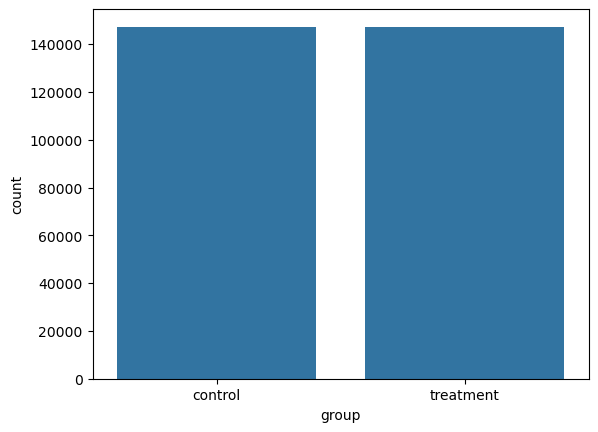

In [82]:
sns.countplot(x = df['group']);

In [83]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='object')

In [84]:
df.head(1)

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0


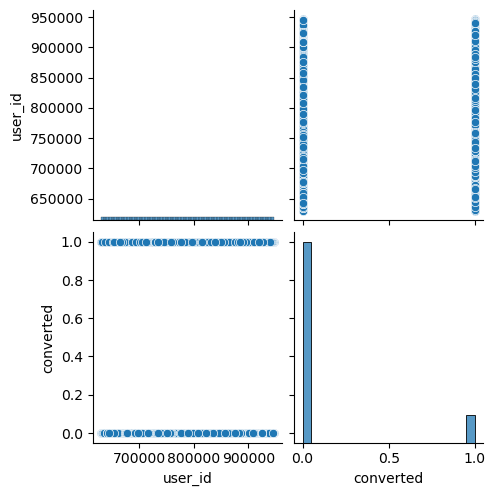

In [85]:
sns.pairplot(df);

In [86]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of unique users: {df.user_id.nunique()}')

Number of rows: 294478
Number of unique users: 290584


In [87]:
# Чи збігаються номери new_page та treatment?
n_treat = df[df["group"] == "treatment"].shape[0]
n_new_page = df[df["landing_page"] == "new_page"].shape[0]
difference = n_treat - n_new_page

pd.DataFrame({
    'N treatment': [n_treat],
    'N new_page': [n_new_page],
    'Difference': [difference]
})

,N treatment,N new_page,Difference
0,147276,147239,37


In [88]:
# unmatch 
df[(df["group"] == "treatment") & (df["landing_page"] == "old_page")]

,user_id,timestamp,group,landing_page,converted
308,857184,34:59.8,treatment,old_page,0
327,686623,26:40.7,treatment,old_page,0
357,856078,29:30.4,treatment,old_page,0
685,666385,11:54.8,treatment,old_page,0
713,748761,47:44.4,treatment,old_page,0
...,...,...,...,...,...
293773,688144,34:50.5,treatment,old_page,1
293817,876037,15:09.0,treatment,old_page,1
293917,738357,37:55.7,treatment,old_page,0
294014,813406,25:33.2,treatment,old_page,0


In [89]:
df_mismatch = df[(df["group"] == "treatment") & (df["landing_page"] == "old_page")
               |(df["group"] == "control") & (df["landing_page"] == "new_page")]

n_mismatch = df_mismatch.shape[0]

percent_mismatch = round(n_mismatch / len(df) * 100, 2)
print(f'Number of mismatched rows: {n_mismatch} rows')
print(f'Percent of mismatched rows: {percent_mismatch} percent')

Number of mismatched rows: 3893 rows
Percent of mismatched rows: 1.32 percent


In [90]:
df2 = df[(df["group"] == "treatment") & (df["landing_page"] == "new_page")
        |(df["group"] == "control") & (df["landing_page"] == "old_page")]

len(df2), len(df)

(290585, 294478)

In [91]:
# df2

In [92]:
df2['user_id'].value_counts()

user_id
773192    2
851104    1
688307    1
718297    1
838144    1
         ..
755610    1
804629    1
837875    1
889019    1
715931    1
Name: count, Length: 290584, dtype: int64

In [93]:
df2[df2.duplicated("user_id") == True]

,user_id,timestamp,group,landing_page,converted
2893,773192,55:59.6,treatment,new_page,0


#### Частина 2. Probability

In [94]:
df2.converted.mean() * 100

11.959667567149026

In [95]:
df2.user_id = df2.user_id.astype(str)
# df2.groupby("group").mean()

In [96]:
df2.groupby('group')['converted'].mean() * 100.0

group
control      12.038630
treatment    11.880725
Name: converted, dtype: float64

In [97]:
df2.groupby("group")['user_id'].count()

group
control      145274
treatment    145311
Name: user_id, dtype: int64

In [98]:
pd.DataFrame(df2.landing_page.value_counts(normalize = True) * 100)

,proportion
landing_page,
new_page,50.006366
old_page,49.993634


> Чи є достатньо доказів, щоб зробити висновок, що нова сторінка призводить до більшої кількості конверсій? \
> Імовірність того, що особа отримала нову сторінку, становить 50%. \
> Імовірність того, що особа здійснить конверсію незалежно від сторінки, яку вона отримала, становить 11,96%. \
> Враховуючи, що особа перебувала в контрольній групі, ймовірність її конверсії становить 12,04%. \
> Враховуючи, що особа перебувала в групі , ймовірність її конверсії становить 11,88%. \
> 1 до 4 свідчить про те, що між групою  та контрольною групою немає істотної різниці в конверсії. Отже, ми можемо зробити висновок, що нова сторінка  не має впливу і не призводить до збільшення кількості конверсій.


#### Частина 3. A/B Test

In [99]:
means_diff = []
size = df.shape[0]
for _ in range(10_00):
    sample = df2.sample(size, replace = True)
    control_mean = sample[sample["group"] == "control"]["converted"].mean()
    treat_mean = sample[sample["group"] == "treatment"]["converted"].mean()
    means_diff.append(treat_mean - control_mean)

KeyboardInterrupt: 

In [ ]:
means_diff = np.array(means_diff)
null_vals = np.random.normal(0, means_diff.std(), means_diff.size)

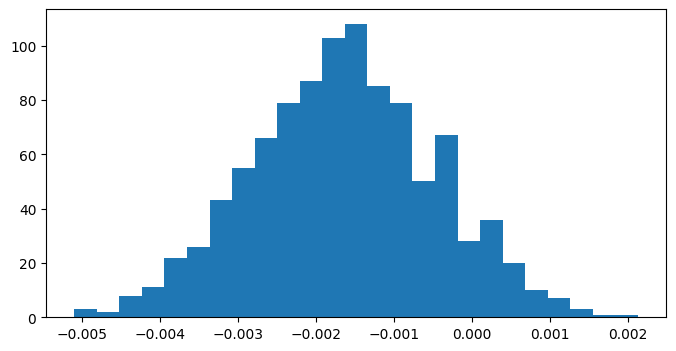

In [ ]:
plt.figure(figsize = (8,4), dpi = 100)
plt.hist(means_diff, bins = 25)
plt.show()

In [ ]:
# plt.figure(figsize = (8,4), dpi = 100)
# plt.hist(null_vals, bins = 25)
# plt.show()

NameError: name 'null_vals' is not defined

<Figure size 800x400 with 0 Axes>

In [ ]:
control_mean = df2[df2["group"] == "control"]["converted"].mean()
treat_mean = df2[df2["group"] == "treatment"]["converted"].mean()
obs_diff = treat_mean - control_mean

plt.figure(figsize = (8,4), dpi = 100)
plt.hist(null_vals, bins = 25)
plt.axvline(obs_diff, c='red')
plt.show()

NameError: name 'null_vals' is not defined

<Figure size 800x400 with 0 Axes>

In [ ]:
(null_vals > obs_diff).mean()

In [ ]:
pd.crosstab(df2["group"], df2["landing_page"])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [ ]:
conv = df2.groupby("group")["converted"].agg(["sum", "count"])
conv

,sum,count
group,,
control,17489,145274
treatment,17264,145311


In [ ]:
control = df2[df2.group == "control"]["converted"]
treat   = df2[df2.group == "treatment"]["converted"]

In [ ]:
n_c = len(control)
n_t = len(treat)

x_c = control.sum()
x_t = treat.sum()

In [ ]:
# Рахуємо конверсію 
p_c = x_c / n_c
p_t = x_t / n_t

p_c, p_t, p_t - p_c


(np.float64(0.1203863045004612),
 np.float64(0.11880724790277405),
 np.float64(-0.0015790565976871451))

In [ ]:
from scipy.stats import norm

p_pool = (x_c + x_t) / (n_c + n_t)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))

z = (p_t - p_c) / se

p_value = 2 * (1 - norm.cdf(abs(z)))

z, p_value


(np.float64(-1.3116075339133115), np.float64(0.18965258971881793))

In [ ]:
table = np.array([
    [control.sum(), control.count() - control.sum()],
    [treat.sum(),   treat.count()   - treat.sum()]
])

table

array([[ 17489, 127785],
       [ 17264, 128047]])

In [ ]:
# Chi2
# H0 - між А і B в нас не має 
# H1 - різниця є
# x^2 = sum(O - E^2 / E)
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table) # a = 0.05 
chi2, p_value


(np.float64(1.7053502645115), np.float64(0.19158976298516012))

In [ ]:
# Fisher 
from scipy.stats import fisher_exact

odds_ratio, p_value = fisher_exact(table)
odds_ratio, p_value


(np.float64(1.0151099413319618), np.float64(0.19047607131914912))

In [ ]:
mde = (z_alpha + z_beta) * np.sqrt(2 * p0 * (1 - p0) / n)

mde

---
#### Self practise

In [ ]:
# Index
# user id User ID (unique)

# test group: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement

# converted: If a person bought the product then True, else is False

# total ads: Amount of ads seen by person

# most ads day: Day that the person saw the biggest amount of ads

# most ads hour: Hour of day that the person saw the biggest amount of ads

---
#### Part 1. Data Cleaning and EDA

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('marketing_AB.csv')

In [ ]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
df.tail(2)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


In [ ]:
df.sample(4)

,id,time,con_treat,page,converted
245033,655522,53:55.3,control,old_page,0
14424,906381,42:06.7,control,old_page,0
68023,659226,56:55.5,treatment,new_page,0
33173,651464,09:58.4,treatment,new_page,0


In [ ]:
df.shape

(294478, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [ ]:
df.isna().sum()

id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

In [ ]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [ ]:
group_count = df.groupby('test group')['user id'].count()
group_count

test group
ad     564577
psa     23524
Name: user id, dtype: int64

In [ ]:
convert_df = df.groupby('test group')['converted'].sum()
convert_df

test group
ad     14423
psa      420
Name: converted, dtype: int64

In [ ]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of unique users: {df['user id'].nunique()}')

Number of rows: 588101
Number of unique users: 588101


In [ ]:
control_mean = df[df["test group"] == "ad"]["converted"].mean()
treat_mean = df[df["test group"] == "psa"]["converted"].mean()
print(control_mean)
print(treat_mean )

0.025546559636683747
0.01785410644448223


In [ ]:

n_ad = df[df["test group"] == "ad"].shape[0]
n_psa = df[df["test group"] == "psa"].shape[0]
difference = n_ad - n_psa

pd.DataFrame({
    'N ad': [n_ad],
    'N psa': [n_psa],
    'Difference': [difference]
})

,N ad,N psa,Difference
0,564577,23524,541053


In [ ]:
df_mismatch = df[(df["test group"] == "ads") 
               |(df["test group"] == "psa") ]

n_mismatch = df_mismatch.shape[0]

percent_mismatch = round(n_mismatch / len(df) * 100, 2)
print(f'Number of mismatched rows: {n_mismatch} rows')
print(f'Percent of mismatched rows: {percent_mismatch} percent')

Number of mismatched rows: 23524 rows
Percent of mismatched rows: 4.0 percent


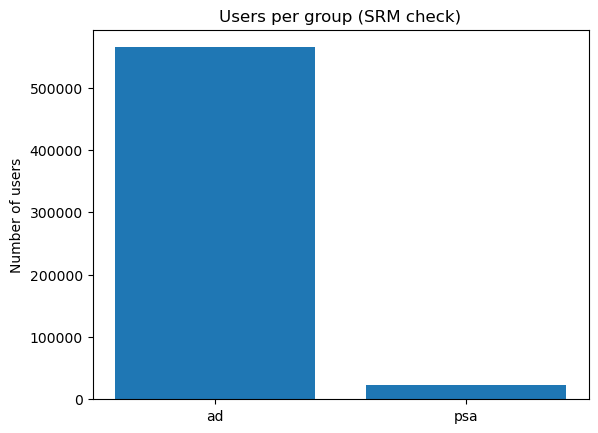

In [ ]:
# SRM
import matplotlib.pyplot as plt

group_counts = df["test group"].value_counts()

plt.bar(group_counts.index, group_counts.values)
plt.title("Users per group (SRM check)")
plt.ylabel("Number of users")
plt.show()


converted    False  True 
test group               
ad          550154  14423
psa          23104    420


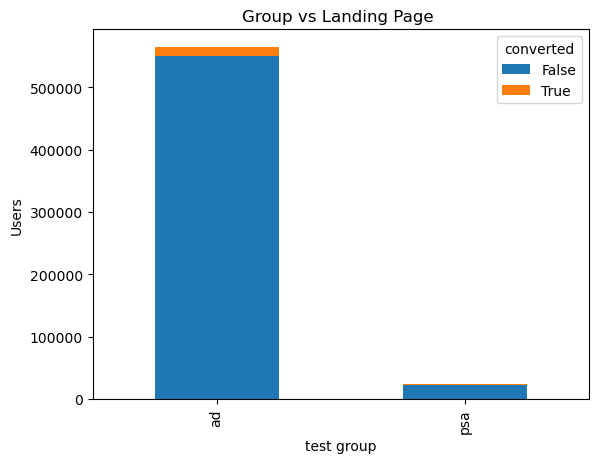

In [ ]:
ct = pd.crosstab(df["test group"], df["converted"])
print(ct)
ct.plot(kind="bar", stacked=True)
plt.title("Group vs Landing Page ")
plt.ylabel("Users")
plt.show()


In [ ]:
df_clear = df.drop_duplicates(subset='user id')
df_clear = df.drop(columns=['Unnamed: 0'])
df_clear.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


Основні висновки після EDA (Exploratory Data Analysis)

- Дані не містять пропущених значень та дублікатів. 
- Кількість спостережень у групах A та B не є порівнюваною, що збільшує ризик перекосу результатів тесту.
- Користувачі не рівномірно розподілені між тестовими групами.
- Було видалено стовпчик Unnamed: 0, який не є інформативним для поставленної задачі

Дані очищені, структуровані та підготовлені до проведення статистичного тестування.
EDA підтвердив коректність даних і дозволив перейти до перевірки гіпотез.

---
#### Part 2. Probability

In [ ]:
df_clear["converted"].mean() * 100

2.523886203220195

In [ ]:
df_clear.groupby('test group')['converted'].mean() * 100.0

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64

In [ ]:
df_clear.groupby('test group')['user id'].count()

test group
ad     564577
psa     23524
Name: user id, dtype: int64

In [ ]:
pd.DataFrame(df_clear['test group'].value_counts(normalize = True) * 100)


,proportion
test group,
ad,96.000007
psa,3.999993


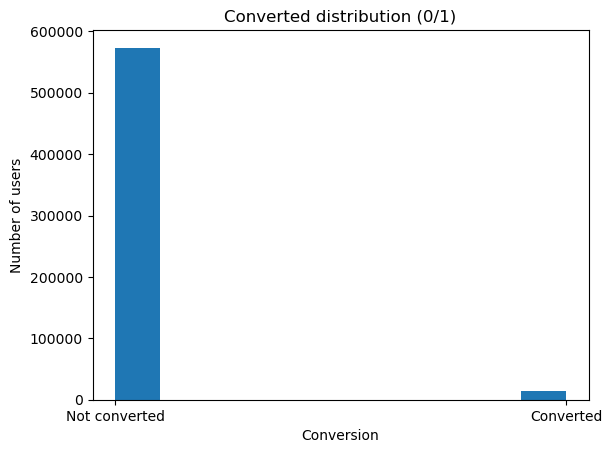

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_clear['converted'].astype(int))
plt.title("Converted distribution (0/1)")
plt.xticks([0, 1], ["Not converted", "Converted"])
plt.xlabel("Conversion")
plt.ylabel("Number of users")
plt.show()

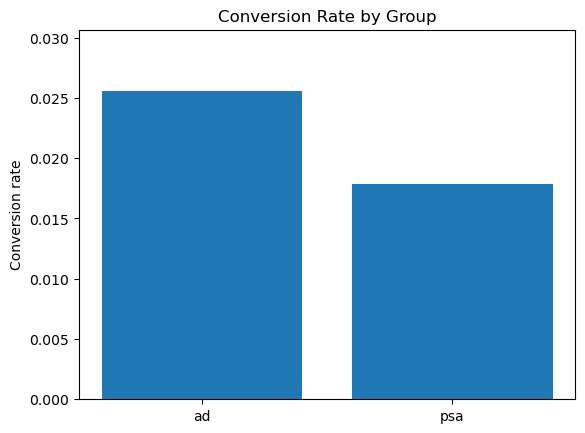

In [ ]:
cr = df_clear.groupby('test group')['converted'].mean()

plt.bar(cr.index, cr.values)
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion rate")
plt.ylim(0, cr.max() * 1.2)
plt.show()


> Чи є достатньо доказів, щоб зробити висновок, що група яка не дивилась рекламу призведе до більшої кількості конверсій? - НІ \
> Імовірність того, що особа здійснить конверсію незалежно від виду реклами, яку вона побачила, становить - 2,52%. \
> Враховуючи, що особа перебувала в тестовій групі, ймовірність її конверсії становить 2,55%. \
> Враховуючи, що особа перебувала в контрольній групі (не бачили рекламу), ймовірність її конверсії становить 1,79%. \
> Різниця конверсій 2,55% - 1,79% = 0,76%  свідчить про те, що між тестовою групою та контрольною групою немає істотної різниці в конверсії. Отже, ми можемо зробити висновок, що показ реклами не має впливу і не призводить до збільшення кількості конверсій.

---
#### Part 3. A/B test

In [ ]:
# psa - Контрольна група - без реклами
# ad - Тестова група - користувачі, яким показували рекламу

In [124]:
from scipy.stats import norm

conv_psa = df_clear[df_clear['test group'] == "psa"]["converted"]
conv_ad = df_clear[df_clear['test group'] == "ad"]["converted"]

# Рахуємо конверсії 
p1 = conv_psa.mean() 
p2 = conv_ad.mean() 

print("conv_psa:", p1)
print("conv_ad:", p2)
print()

# Рахуємо Ефект (Effect / Uplift) (Ефект — це різниця значень метрики між тестовою і контрольної групами)

effect =p2 - p1
uplift = (effect / p2) * 100

print(f"Effect: {effect:.4f}")
print(f"Uplift: {uplift:.2f}%")
print()

n1 = len(conv_ad)
n2 = len(conv_psa)

# Об’єднана конверсія 
p_pool = (conv_ad.sum() + conv_psa.sum()) / (n1 + n2)

# Стандартна похибка(SE)
SE = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
print('SE:', SE)

# Z-статистика 
z = (p2 - p1) / SE

p_value = 2 * (1 - norm.cdf(abs(z)))

print('Z-статистикаz:', z)
print('P-value:', p_value)

conv_psa: 0.01785410644448223
conv_ad: 0.025546559636683747

Effect: 0.0077
Uplift: 30.11%

SE: 0.0010437410649006525
Z-статистикаz: 7.3700781265454145
P-value: 1.7053025658242404e-13


A/B-тест показав статистично значуще зростання conversion rate у тестовій групі (ad) порівняно з контрольною (psa). Абсолютний ефект становить +0.77 п.п., що відповідає відносному uplift +43.1%. Результат є статистично значущим (p-value ≪ 0.05), тому нульову гіпотезу відхиляємо.

Бізнес-висновок
- Реклама ефективна
- Варіант ad рекомендований до впровадження
- Ефект не випадковий, а підтверджений статистично

In [116]:
# Зробити chi^2 test

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table) 
chi2, p_value

# p_value < α = 0.05 -> незалежність відхиляємо -> є ефект

(54.005823883685245, 1.9989623063390078e-13)

За результатами χ²-тесту (χ² = 54.01, p-value < 0.05) нульову гіпотезу було відхилено.
Виявлено статистично значущу різницю в конверсії між тестовою та контрольною групами, що підтверджує ефективність тестового варіанту.

In [125]:
# Зробити bootstrap

import numpy as np

def bootstrap_diff(a, b, n_boot=10000):
    diffs = []
    for _ in range(n_boot):
        a_sample = np.random.choice(a, size=len(a), replace=True)
        b_sample = np.random.choice(b, size=len(b), replace=True)
        diffs.append(b_sample.mean() - a_sample.mean())
    return np.percentile(diffs, [2.5, 97.5])

ci = bootstrap_diff(conv_psa.values, conv_ad.values)
ci

# CI не містить 0 -> ефект є


array([0.00599025, 0.00941946])

CI не містить 0 -> різниця статистично значуща \
Увесь CI позитивний -> CR_ad > CR_psa \
Реклама підвищує конверсію приблизно на 0.6–0.9 процентних пунктів.

За результатами bootstrap-аналізу 95% довірчий інтервал для різниці conversion rate (ad − psa) становить [0.0059; 0.0094] і не містить нуль. Це свідчить про статистично значущий позитивний ефект реклами.